In [20]:
## test1
from bigrams import BIGRAM_BAG

print(len(BIGRAM_BAG))
print(BIGRAM_BAG[:5])

40
['th', 'he', 'in', 'er', 'an']


In [21]:
## test2
from text_processing import count_tracked_bigrams, counts_to_vector

sentence = "The queen quickly quit the quiet quiz"
counts = count_tracked_bigrams(sentence)
print(counts)

vector = counts_to_vector(counts)
print(vector)

Counter({'th': 2, 'he': 2, 'en': 1, 'ic': 1, 'it': 1})
[2. 2. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [22]:
## test 3
from typing_env import TypingEnv

env = TypingEnv()
env.reset()

for _ in range(5):
    state, reward, _, _ = env.step(0)
    print("Reward:", reward)

Avg skill before: 0.24805354848189132
Avg skill after : 0.2574420266580623
Reward: 0.13324796968137317
Avg skill before: 0.2574420266580623
Avg skill after : 0.26400722718247366
Reward: 0.054384014640059486
Avg skill before: 0.26400722718247366
Avg skill after : 0.269153097221856
Reward: 0.029118288689692712
Avg skill before: 0.269153097221856
Avg skill after : 0.2801790786129521
Reward: 0.014891502088668324
Avg skill before: 0.2801790786129521
Avg skill after : 0.28554629921535496
Reward: -0.07674240918751682


In [23]:
## test 4
env.sample_sentence(0,1)

'gather the thick leather cloth and put it on the shelf'

### we can see the skill growing, as we ran 5 iterations, and rewards are positive.

In [24]:
## test 5
env = TypingEnv()
state = env.reset()

for _ in range(5):
    action = 0  # same bigram
    state, reward, _, _ = env.step(action)
    print("Reward:", reward)
    print("Skill:", env.k[0])

Avg skill before: 0.25051030291673315
Avg skill after : 0.2551428142271786
Reward: 0.12033642973448021
Skill: 0.3521557835292109
Avg skill before: 0.2551428142271786
Avg skill after : 0.2637745714736003
Reward: 0.1141508002296435
Skill: 0.4682338844738275
Avg skill before: 0.2637745714736003
Avg skill after : 0.27056765455389575
Reward: 0.021869993437538898
Skill: 0.5444576423065187
Avg skill before: 0.27056765455389575
Avg skill after : 0.2737278578383405
Reward: -0.06906566451194018
Skill: 0.5934309822884248
Avg skill before: 0.2737278578383405
Avg skill after : 0.2807293759367468
Reward: -0.08288227583481403
Skill: 0.6517088932787819


### Forgetting Curve

Avg skill before: 0.25173673142809444
Avg skill after : 0.27579327980785695
Avg skill before: 0.27579327980785695
Avg skill after : 0.28854967115955976
Avg skill before: 0.28854967115955976
Avg skill after : 0.3017938257544359
Avg skill before: 0.3017938257544359
Avg skill after : 0.3183089348046677
Avg skill before: 0.3183089348046677
Avg skill after : 0.33873718645609896
Avg skill before: 0.33873718645609896
Avg skill after : 0.3554949927830508
Avg skill before: 0.3554949927830508
Avg skill after : 0.37300978936919604
Avg skill before: 0.37300978936919604
Avg skill after : 0.3867389988821883
Avg skill before: 0.3867389988821883
Avg skill after : 0.4039267251304854
Avg skill before: 0.4039267251304854
Avg skill after : 0.4191654427617724
Avg skill before: 0.4191654427617724
Avg skill after : 0.43143890795560375
Avg skill before: 0.43143890795560375
Avg skill after : 0.4447841337750512
Avg skill before: 0.4447841337750512
Avg skill after : 0.4541624136143779
Avg skill before: 0.4541624

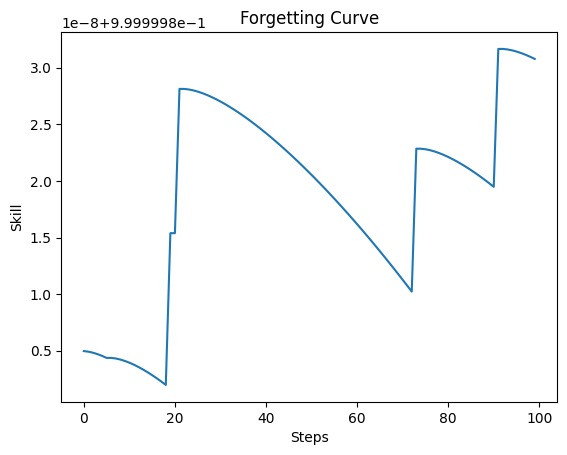

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from typing_env import TypingEnv


env = TypingEnv()
state = env.reset()

target_bigram = 39
difficulty = 3
action = target_bigram * env.L + difficulty

# forgetting curve experiment
env.reset()

learning_steps = 100
forget_steps = 100

forget_curve = []

# learn first
for step in range(learning_steps):
    state, reward, done, _ = env.step(action)

# stop practicing target bigram
for step in range(forget_steps):
    random_action = np.random.randint(0, env.K * env.L)
    state, reward, done, _ = env.step(31)
    forget_curve.append(env.k[target_bigram])

print(forget_curve)

plt.plot(forget_curve)
plt.title("Forgetting Curve")
plt.xlabel("Steps")
plt.ylabel("Skill")

plt.show()

In [26]:
import pandas as pd
df = pd.read_csv("typing_dataset.csv")
df.head()


,sentence,target_bigram,difficulty
0,the thin cat sat on the mat,th,0
1,this path has the moth on it,th,0
2,that cloth has both the moths,th,0
3,the bath with the thick cloth,th,0
4,both the teeth and the cloth,th,0


In [27]:

for i in range(20):
    j = i // 20
    if(i==0):
        print(f"for bigram {BIGRAM_BAG[j]}")
    sentence = df['sentence'][i]
    print(count_tracked_bigrams(sentence)[BIGRAM_BAG[j]])
    

for bigram th
3
4
5
6
5
5
5
5
5
5
5
5
5
6
5
5
5
5
5
5


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from typing_env import TypingEnv

In [29]:
def run_random_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    K = env.K
    L = env.L
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = np.random.randint(0, K * L)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])  # final skill
        
    return all_rewards, all_skills

In [30]:
def select_action(env):
    
    scores = env.k - 0.1 * env.t
    weakest_bigram = np.argmin(scores)
    
    skill = env.k[weakest_bigram]
    
    if skill < 0.3:
        difficulty = 0
    elif skill < 0.5:
        difficulty = 1
    elif skill < 0.7:
        difficulty = 2
    elif skill < 0.85:
        difficulty = 3
    else:
        difficulty = 4
    
    return weakest_bigram * env.L + difficulty

In [31]:
def run_rule_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = select_action(env)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])
        
    return all_rewards, all_skills

In [32]:
random_rewards, random_skills = run_random_agent()
rule_rewards, rule_skills = run_rule_agent()

Avg skill before: 0.24790416164194054
Avg skill after : 0.2598957464558784
Avg skill before: 0.2598957464558784
Avg skill after : 0.2626690775207834
Avg skill before: 0.2626690775207834
Avg skill after : 0.26729110488839175
Avg skill before: 0.26729110488839175
Avg skill after : 0.28424492054435485
Avg skill before: 0.28424492054435485
Avg skill after : 0.2980355242131802
Avg skill before: 0.2980355242131802
Avg skill after : 0.30174562847994946
Avg skill before: 0.30174562847994946
Avg skill after : 0.31906377063471253
Avg skill before: 0.31906377063471253
Avg skill after : 0.3249728744355071
Avg skill before: 0.3249728744355071
Avg skill after : 0.33185733572868215
Avg skill before: 0.33185733572868215
Avg skill after : 0.3407051270062584
Avg skill before: 0.3407051270062584
Avg skill after : 0.35647618359447125
Avg skill before: 0.35647618359447125
Avg skill after : 0.3636518046402136
Avg skill before: 0.3636518046402136
Avg skill after : 0.373049188635335
Avg skill before: 0.373049

In [33]:
print("Random avg skill:", np.mean(random_skills))
print("Rule avg skill:", np.mean(rule_skills))

print("Random avg reward:", np.mean(random_rewards))
print("Rule avg reward:", np.mean(rule_rewards))

Random avg skill: 0.8527646211141514
Rule avg skill: 0.8433967127645432
Random avg reward: 0.2067939012932003
Rule avg reward: 0.13171004333862882


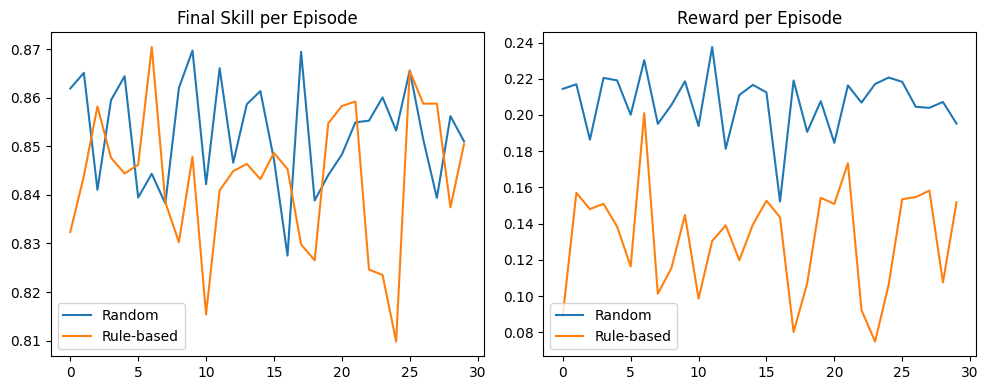

In [34]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(random_skills, label="Random")
plt.plot(rule_skills, label="Rule-based")
plt.title("Final Skill per Episode")
plt.legend()

plt.subplot(1,2,2)
plt.plot(random_rewards, label="Random")
plt.plot(rule_rewards, label="Rule-based")
plt.title("Reward per Episode")
plt.legend()

plt.tight_layout()
plt.show()

## test for q_learning agent

In [35]:
from q_learning import QLearningAgent

agent = QLearningAgent()

rewards, skills = agent.train(
    episodes=10,
    steps_per_episode=300
)

Avg skill before: 0.24766395328200788
Avg skill after : 0.26309445161601186
Avg skill before: 0.26309445161601186
Avg skill after : 0.28360041759643684
Avg skill before: 0.28360041759643684
Avg skill after : 0.2894818916382359
Avg skill before: 0.2894818916382359
Avg skill after : 0.3031947080971421
Avg skill before: 0.3031947080971421
Avg skill after : 0.3191403476600805
Avg skill before: 0.3191403476600805
Avg skill after : 0.3308179247295345
Avg skill before: 0.3308179247295345
Avg skill after : 0.3471901003557926
Avg skill before: 0.3471901003557926
Avg skill after : 0.3504400789774562
Avg skill before: 0.3504400789774562
Avg skill after : 0.3539471950125974
Avg skill before: 0.3539471950125974
Avg skill after : 0.3683798105580146
Avg skill before: 0.3683798105580146
Avg skill after : 0.3732042892339501
Avg skill before: 0.3732042892339501
Avg skill after : 0.3859189715594568
Avg skill before: 0.3859189715594568
Avg skill after : 0.3893457441162572
Avg skill before: 0.3893457441162

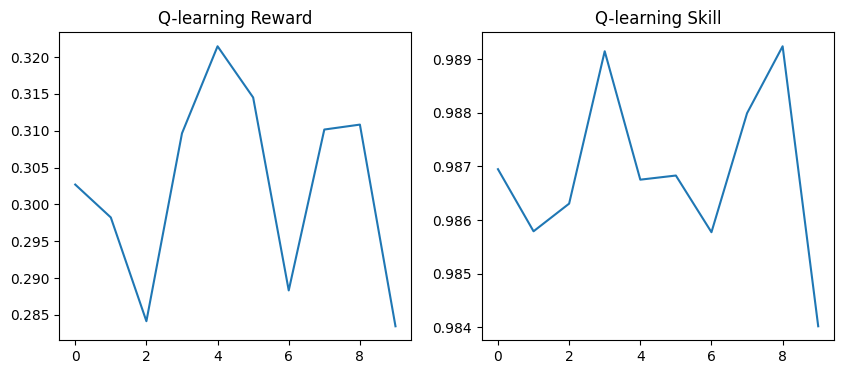

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(rewards)
plt.title("Q-learning Reward")

plt.subplot(1,2,2)
plt.plot(skills)
plt.title("Q-learning Skill")

plt.show()

## test for DQN agent

In [37]:
from dqn_agent import DQNAgent

agent = DQNAgent()

rewards, skills = agent.train(
    episodes=10,
    steps_per_episode=300
)

Avg skill before: 0.2526863127989259
Avg skill after : 0.26088384261216896
Avg skill before: 0.26088384261216896
Avg skill after : 0.2765911630033465
Avg skill before: 0.2765911630033465
Avg skill after : 0.2795502325388751
Avg skill before: 0.2795502325388751
Avg skill after : 0.2895902255948915
Avg skill before: 0.2895902255948915
Avg skill after : 0.3094384935462349
Avg skill before: 0.3094384935462349
Avg skill after : 0.3184142641018272
Avg skill before: 0.3184142641018272
Avg skill after : 0.3313549732813115
Avg skill before: 0.3313549732813115
Avg skill after : 0.34584063529552145
Avg skill before: 0.34584063529552145
Avg skill after : 0.3581342270993459
Avg skill before: 0.3581342270993459
Avg skill after : 0.37322882281817116
Avg skill before: 0.37322882281817116
Avg skill after : 0.3889542338010579
Avg skill before: 0.3889542338010579
Avg skill after : 0.40556338362647065
Avg skill before: 0.40556338362647065
Avg skill after : 0.409718361012448
Avg skill before: 0.40971836101

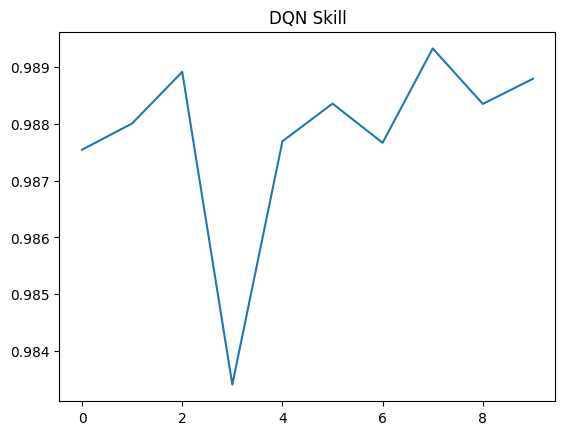

In [38]:
import matplotlib.pyplot as plt

plt.plot(skills)
plt.title("DQN Skill")
plt.show()